In [1]:
import pandas as pd
import tensorflow as tf
import numpy as np
import gc
import time
#import matplotlib.pyplot as plt
#from livelossplot.keras import PlotLossesCallback
from tensorflow.keras.callbacks import ReduceLROnPlateau
#from keras.models import load_model
import csv
from itertools import chain
from matplotlib import pyplot as plt

D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\s

### 设置GPU显存按需分配

In [2]:
#如果没有装GPU版本，这部分就不用写，但是如果不用GPU加速计算，使用CPU将会严重限制模型的训练速度
gpus = tf.config.experimental.list_physical_devices('GPU') 
if gpus:
  try:

    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:

    print(e)

1 Physical GPUs, 1 Logical GPUs


### 载入数据

In [3]:
data_train=pd.read_csv('F:/TensorFlow/traindata20230508.csv',header=0,encoding='utf_8')
data_train.info()
data_train.ClassName.unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24660 entries, 0 to 24659
Columns: 257 entries, ClassName to Wgs84Y
dtypes: float64(26), int64(230), object(1)
memory usage: 48.4+ MB


array(['荒漠', '膜果麻黄（Ephedra przewalskii）荒漠', '盐爪爪（Kalidium foliatum）荒漠',
       '芨芨草（Achnatherum splendens）草甸', '矮生嵩草（Kobresia humilis）草甸',
       '垂穗披碱草（Elymus nutans）高寒草甸', '高山嵩草（Kobresia pygmaea）草甸',
       '高山薹草（Carex pseudosupina）草原', '紫花针茅（Stipa purpurea）草原',
       '早熟禾、垂穗披碱草高寒草甸', '线叶嵩草（Kobresia capillifolia）草甸',
       '金露梅（Potentilla fruticosa）灌丛', '鹅绒委陵菜（Potentilla anserina）高寒草甸',
       '垫状金露梅（Potentilla fruticosa var. pumila）灌丛',
       '藏北嵩草（Kobresia littledalei）沼泽草甸', '细叶嵩草（Kobresia filifolia）草甸',
       '扇穗茅（Littledalea racemosa）高寒草原',
       '藏嵩草（Kobresia vchaenoides=Kobresia tibetica）沼泽草甸',
       '青藏薹草（Carex moorcroftii）高寒草原', '嵩草（Kobresia spp.）草甸',
       '冰草（Agropyron cristatum）草原', '短花针茅（Stipa breviflora）荒漠草原',
       '芨芨草（Achnatherum splendens）草原', '赖草（Leymus secalinus）草甸',
       '长芒草（Stipa bungeana）草原', '沙生针茅（Stipa glareosa）荒漠草原',
       '华扁穗草（Blysmus sinocompressus）沼泽化草甸', '羊茅（Festuca ovina）杂类草草甸',
       '糙喙薹草（Carex scabrirostris）草甸', '小叶金露梅（Potentilla parvifo

In [4]:
pd.set_option('display.max_rows', None)
print(data_train['ClassName'].value_counts())

高山嵩草（Kobresia pygmaea）草甸                                                     5561
紫花针茅（Stipa purpurea）草原                                                       2067
矮生嵩草（Kobresia humilis）草甸                                                     1381
垂穗披碱草（Elymus nutans）高寒草甸                                                     1112
线叶嵩草（Kobresia capillifolia）草甸                                                 458
藏嵩草（Kobresia vchaenoides=Kobresia tibetica）沼泽草甸                               451
青藏薹草（Carex moorcroftii）高寒草原                                                   441
长芒草（Stipa bungeana）草原                                                         372
藏北嵩草（Kobresia littledalei）沼泽草甸                                                317
细叶早熟禾（Poa pratensis subsp. angustifolia）草甸草原                                  317
芨芨草（Achnatherum splendens）草原                                                  282
圆穗蓼（Polygonum macrophyllum）、珠芽蓼（Polygonum viviparum）高寒草甸                      266
沙生风毛菊（Saussurea 

In [5]:
data_train.head()

,ClassName,num,AET1901,AET1902,AET1903,AET1904,AET1905,AET1906,AET1907,AET1908,...,SR190829B7,SR190930B1,SR190930B2,SR190930B3,SR190930B4,SR190930B5,SR190930B6,SR190930B7,Wgs84X,Wgs84Y
0,荒漠,0,0,0,0,569,641,172,909,500,...,2315,3924,3623,2090,2492,2813,2333,1986,88.103636,28.158935
1,荒漠,0,0,0,0,569,641,172,909,500,...,2315,3924,3623,2090,2492,2813,2333,1986,88.103628,28.159233
2,荒漠,0,0,0,0,766,716,215,953,617,...,1790,1527,3059,1231,2011,3589,3697,3268,87.828855,28.327443
3,荒漠,0,0,0,0,56,1009,417,408,576,...,1717,1254,2300,931,1392,2789,2715,2324,83.346677,30.124012
4,荒漠,0,0,0,0,112,1093,358,224,233,...,980,828,1290,556,838,1670,1533,1175,84.919036,29.596544


In [6]:
# 生成该区间的随意唯一索引
index = np.random.permutation(len(data_train))
# 用生成的乱的索引就能将其打乱了
data_all = data_train.iloc[index ,:]

### 类别数量

In [7]:
num_classes = data_train['ClassName'].nunique()
print(num_classes)

140


### 不测试时使用全部数据训练

In [8]:
train_x = data_train.iloc[:,2:]
train_y = data_train.loc[:, ['num']] 

In [9]:
train_x.head()

,AET1901,AET1902,AET1903,AET1904,AET1905,AET1906,AET1907,AET1908,AET1909,AET1910,...,SR190829B7,SR190930B1,SR190930B2,SR190930B3,SR190930B4,SR190930B5,SR190930B6,SR190930B7,Wgs84X,Wgs84Y
0,0,0,0,569,641,172,909,500,590,198,...,2315,3924,3623,2090,2492,2813,2333,1986,88.103636,28.158935
1,0,0,0,569,641,172,909,500,590,198,...,2315,3924,3623,2090,2492,2813,2333,1986,88.103628,28.159233
2,0,0,0,766,716,215,953,617,790,194,...,1790,1527,3059,1231,2011,3589,3697,3268,87.828855,28.327443
3,0,0,0,56,1009,417,408,576,238,101,...,1717,1254,2300,931,1392,2789,2715,2324,83.346677,30.124012
4,0,0,0,112,1093,358,224,233,296,271,...,980,828,1290,556,838,1670,1533,1175,84.919036,29.596544


### 顺序编码转独热编码

In [10]:
train_y = tf.keras.utils.to_categorical(train_y)

In [11]:
train_x.head()
train_y

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)

### 定义损失函数为Focal Loss

In [12]:
def multi_category_focal_loss2(gamma=2., alpha=.25):
    """
    focal loss for multi category of multi label problem
    适用于多分类或多标签问题的focal loss
    alpha控制真值y_true为1/0时的权重
        1的权重为alpha, 0的权重为1-alpha
    当你的模型欠拟合，学习存在困难时，可以尝试适用本函数作为loss
    当模型过于激进(无论何时总是倾向于预测出1),尝试将alpha调小
    当模型过于惰性(无论何时总是倾向于预测出0,或是某一个固定的常数,说明没有学到有效特征)
        尝试将alpha调大,鼓励模型进行预测出1。
    Usage:
     model.compile(loss=[multi_category_focal_loss2(alpha=0.25, gamma=2)], metrics=["accuracy"], optimizer='adam')
    """
    epsilon = 1.e-7
    gamma = float(gamma)
    alpha = tf.constant(alpha, dtype=tf.float32)

    def multi_category_focal_loss2_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    
        alpha_t = y_true*alpha + (tf.ones_like(y_true)-y_true)*(1-alpha)
        y_t = tf.multiply(y_true, y_pred) + tf.multiply(1-y_true, 1-y_pred)
        y_t = tf.clip_by_value(y_t, epsilon, 1. - epsilon)#这句是后加的
        ce = -tf.math.log(y_t)
        weight = tf.math.pow(tf.subtract(1., y_t), gamma)
        fl = tf.multiply(tf.multiply(weight, ce), alpha_t)
        loss = tf.reduce_mean(fl)
        return loss
    return multi_category_focal_loss2_fixed

### 模型构建

In [13]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(4096,input_dim=255))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(2048,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(1024,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(512,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(256,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(128,activation='relu'))
#model.add(tf.keras.layers.BatchNormalization())
#model.add(tf.keras.layers.Dense(64,activation='relu'))
#model.add(tf.keras.layers.BatchNormalization())
#model.add(tf.keras.layers.Dense(32,activation='relu'))#注：如果后面再加16，8，16，32这样的全连结层，精度反而会变低
model.add(tf.keras.layers.Dropout(rate=0.5))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))#不懂为啥有时候对不上非要+1
# 让学习率自动变化
reduce_lr = ReduceLROnPlateau(monitor='loss',factor=0.1, patience=20, mode='auto')
model.compile(loss='categorical_crossentropy', metrics=['acc'], optimizer='adam')#adam优化
#顺序编码用loss='sparse_categorical_crossentropy'
#独热编码用loss='categorical_crossentropy'
model.summary()

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 4096)              1048576   
_________________________________________________________________
batch_normalization (BatchNo (None, 4096)              16384     
_________________________________________________________________
dense_1 (Dense)              (None, 2048)              8390656   
_________________________________________________________________
batch_normalization_1 (Batch (None, 2048)              8192      
_________________________________________________________________
dense_2 (Dense)              (None, 1024)              2098176   
_________________________________________________________________
batch_normalization_2 (Batch (None, 1024)              4096      
____

### 开始训练

In [14]:
e = 300
start = time.perf_counter()#time.process_time()测的时间偏长
history = model.fit(train_x,train_y, epochs=e,batch_size=32,verbose=1,callbacks=[reduce_lr])#batch_size=16,validation_data=(validation_x,validation_y)
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

Epoch 1/300
24660/24660 [==============================] - 7s 275us/sample - loss: 3.8920 - acc: 0.2018
Epoch 2/300
24660/24660 [==============================] - 6s 223us/sample - loss: 3.3985 - acc: 0.2289
Epoch 3/300
24660/24660 [==============================] - 5s 220us/sample - loss: 3.0906 - acc: 0.2544
Epoch 4/300
24660/24660 [==============================] - 6s 224us/sample - loss: 2.8631 - acc: 0.2840
Epoch 5/300
24660/24660 [==============================] - 6s 225us/sample - loss: 2.6692 - acc: 0.3147
Epoch 6/300
24660/24660 [==============================] - 6s 225us/sample - loss: 2.5175 - acc: 0.3379
Epoch 7/300
24660/24660 [==============================] - 6s 224us/sample - loss: 2.3755 - acc: 0.3686
Epoch 8/300
24660/24660 [==============================] - 6s 225us/sample - loss: 2.2489 - acc: 0.3908
Epoch 9/300
24660/24660 [==============================] - 6s 225us/sample - loss: 2.1332 - acc: 0.4129
Epoch 10/300
24660/24660 [==============================] - 6s 2

24660/24660 [==============================] - 6s 238us/sample - loss: 0.6898 - acc: 0.7631
Epoch 80/300
24660/24660 [==============================] - 6s 235us/sample - loss: 0.6837 - acc: 0.7665
Epoch 81/300
24660/24660 [==============================] - 6s 234us/sample - loss: 0.6801 - acc: 0.7663
Epoch 82/300
24660/24660 [==============================] - 6s 237us/sample - loss: 0.6698 - acc: 0.7686
Epoch 83/300
24660/24660 [==============================] - 6s 234us/sample - loss: 0.6761 - acc: 0.7675
Epoch 84/300
24660/24660 [==============================] - 6s 238us/sample - loss: 0.6632 - acc: 0.7686
Epoch 85/300
24660/24660 [==============================] - 6s 226us/sample - loss: 0.6746 - acc: 0.7678
Epoch 86/300
24660/24660 [==============================] - 5s 219us/sample - loss: 0.6493 - acc: 0.7733
Epoch 87/300
24660/24660 [==============================] - 5s 221us/sample - loss: 0.6524 - acc: 0.7711
Epoch 88/300
24660/24660 [==============================] - 5s 220us

24660/24660 [==============================] - 5s 217us/sample - loss: 0.5122 - acc: 0.8075
Epoch 157/300
24660/24660 [==============================] - 5s 215us/sample - loss: 0.5064 - acc: 0.8095
Epoch 158/300
24660/24660 [==============================] - 5s 216us/sample - loss: 0.5126 - acc: 0.8032
Epoch 159/300
24660/24660 [==============================] - 5s 217us/sample - loss: 0.5007 - acc: 0.8061
Epoch 160/300
24660/24660 [==============================] - 5s 215us/sample - loss: 0.5203 - acc: 0.8038
Epoch 161/300
24660/24660 [==============================] - 5s 216us/sample - loss: 0.5005 - acc: 0.8071
Epoch 162/300
24660/24660 [==============================] - 5s 217us/sample - loss: 0.5105 - acc: 0.8026
Epoch 163/300
24660/24660 [==============================] - 5s 215us/sample - loss: 0.5007 - acc: 0.8084
Epoch 164/300
24660/24660 [==============================] - 5s 215us/sample - loss: 0.5041 - acc: 0.8082
Epoch 165/300
24660/24660 [==============================] -

24660/24660 [==============================] - 6s 242us/sample - loss: 0.4432 - acc: 0.8205
Epoch 234/300
24660/24660 [==============================] - 6s 245us/sample - loss: 0.4461 - acc: 0.8200
Epoch 235/300
24660/24660 [==============================] - 6s 241us/sample - loss: 0.4551 - acc: 0.8166
Epoch 236/300
24660/24660 [==============================] - 6s 243us/sample - loss: 0.4536 - acc: 0.8179
Epoch 237/300
24660/24660 [==============================] - 6s 241us/sample - loss: 0.4462 - acc: 0.8202
Epoch 238/300
24660/24660 [==============================] - 6s 240us/sample - loss: 0.4548 - acc: 0.8151
Epoch 239/300
24660/24660 [==============================] - 6s 244us/sample - loss: 0.4493 - acc: 0.8197
Epoch 240/300
24660/24660 [==============================] - 6s 240us/sample - loss: 0.4462 - acc: 0.8191
Epoch 241/300
24660/24660 [==============================] - 6s 241us/sample - loss: 0.4448 - acc: 0.8197
Epoch 242/300
24660/24660 [==============================] -

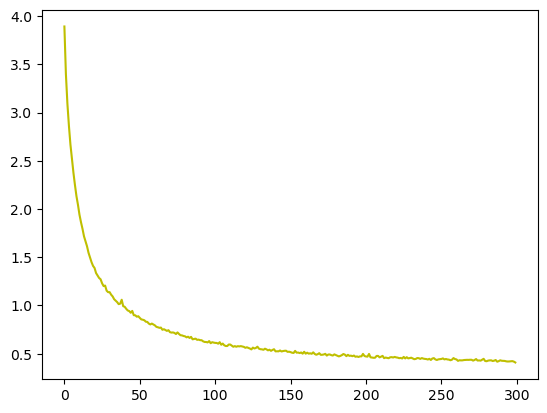

In [15]:
plt.plot(range(300),history.history.get('loss'),color =  'y')

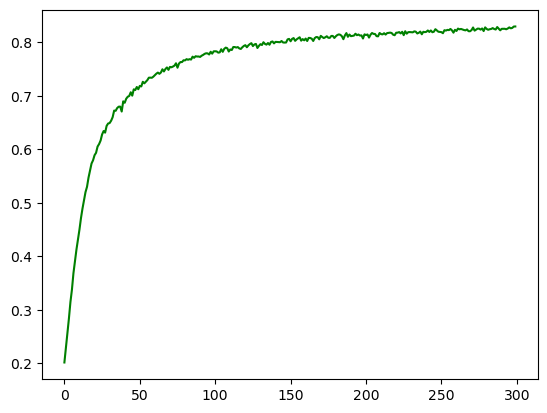

In [16]:
plt.plot(range(300),history.history.get('acc'),color =  'g')

In [17]:
model.save(r'F:/TensorFlow/model_data/model_QTP_20231008.h5')

### 载入测试数据（切分过数据集的话不用此部分）

In [90]:
data_test=pd.read_csv('./testdata20200920.csv',header=0,encoding='gb2312')
data_test.info()
data_test.Code.unique()
# 生成该区间的随意唯一索引
index = np.random.permutation(len(data_test))
# 用生成的乱的索引就能将其打乱了
data_test = data_test.iloc[index ,:]
test_x = data_test.iloc[:,5:]
test_y = data_test.loc[:, ['Code']].values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 409 entries, 0 to 408
Columns: 260 entries, FID to Y
dtypes: float64(26), int64(231), object(3)
memory usage: 830.9+ KB


### 计算准确率

In [63]:
test_r = pd.DataFrame(model.predict_classes(test_x,verbose=1))
test_r = test_r.values
acc_array = (test_y == test_r)
print('准确率：', np.sum(acc_array!=0)/len(acc_array))

3996/3996 [==============================] - 0s 67us/sample
准确率： Value    0.881381
dtype: float64


### 各类别准确率

In [35]:
test_y = list(chain.from_iterable(test_y))
test_r = list(chain.from_iterable(test_r))

def count_nums(true_labels, num_classes):
    initial_value = 0
    list_length = num_classes
    list_data = [ initial_value for i in range(list_length)]
    for i in range(0, num_classes):
        list_data[i] = true_labels.count(i)
    return list_data

def accuracy(confusion_matrix, true_labels, num_classes):
    # 各个类别的测试样本的个数
    list_data = count_nums(true_labels, num_classes)
 
    # 各个类别正确分类的个数
    initial_value = 0
    list_length = num_classes
    true_pred = [ initial_value for i in range(list_length)]
    for i in range(0,num_classes):
        true_pred[i] = confusion_matrix[i][i]
 
    # 计算各个样本被正确分类的正确率
    classveg = []
    acc = []
    for i in range(0, num_classes):
        classveg.append(0)
        acc.append(0)
 
    for i in range(0,num_classes):
        classveg[i] = i
        acc[i] = float(true_pred[i] / list_data[i])
    
    z = pd.DataFrame(list(zip(classveg,acc,list_data)), columns=['class_code', 'acc','count'])
    return z

op = tf.math.confusion_matrix(test_y, test_r)

acc = accuracy(op, test_y, num_classes)
print(acc)

TypeError: 'numpy.int64' object is not iterable

In [6]:
model = tf.keras.models.load_model(r'F:/TensorFlow/model_data/model_QTP_20231005.h5')

AttributeError: 'str' object has no attribute 'decode'

### 出结果

In [18]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk.iloc[:,:-1],verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20230108_p1.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('E:/testdata/testdata20200806_p1+tas+pr.csv',encoding='gb2312')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 3s 34us/sample
1
100000/100000 [==============================] - 3s 33us/sample
2
100000/100000 [==============================] - 3s 32us/sample
3
100000/100000 [==============================] - 3s 32us/sample
4
100000/100000 [==============================] - 4s 35us/sample
5
100000/100000 [==============================] - 3s 33us/sample
6
100000/100000 [==============================] - 3s 34us/sample
7
100000/100000 [==============================] - 4s 35us/sample
8
100000/100000 [==============================] - 3s 34us/sample
9
100000/100000 [==============================] - 3s 33us/sample
10
100000/100000 [==============================] - 3s 33us/sample
11
100000/100000 [==============================] - 3s 33us/sample
12
100000/100000 [==============================] - 3s 33us/sample
13
100000/100000 [==============================] - 3s 32us/sample
14
100000/100000 [==============================] - 3s 33us/sample
15
10

100000/100000 [==============================] - 3s 30us/sample
123
100000/100000 [==============================] - 3s 31us/sample
124
100000/100000 [==============================] - 3s 31us/sample
125
100000/100000 [==============================] - 3s 31us/sample
126
100000/100000 [==============================] - 3s 32us/sample
127
100000/100000 [==============================] - 3s 31us/sample
128
100000/100000 [==============================] - 3s 31us/sample
129
100000/100000 [==============================] - 3s 30us/sample
130
100000/100000 [==============================] - 3s 32us/sample
131
100000/100000 [==============================] - 3s 31us/sample
132
100000/100000 [==============================] - 3s 31us/sample
133
100000/100000 [==============================] - 3s 32us/sample
134
100000/100000 [==============================] - 3s 31us/sample
135
100000/100000 [==============================] - 3s 31us/sample
136
100000/100000 [==============================] -

In [19]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk.iloc[:,:-1],verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20230108_p2.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('E:/testdata/testdata20200806_p2+tas+pr.csv',encoding='gb2312')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 3s 32us/sample
1
100000/100000 [==============================] - 3s 31us/sample
2
100000/100000 [==============================] - 3s 32us/sample
3
100000/100000 [==============================] - 3s 31us/sample
4
100000/100000 [==============================] - 3s 31us/sample
5
100000/100000 [==============================] - 3s 32us/sample
6
100000/100000 [==============================] - 3s 32us/sample
7
100000/100000 [==============================] - 3s 32us/sample
8
100000/100000 [==============================] - 3s 32us/sample
9
100000/100000 [==============================] - 3s 31us/sample
10
100000/100000 [==============================] - 3s 31us/sample
11
100000/100000 [==============================] - 3s 31us/sample
12
100000/100000 [==============================] - 3s 31us/sample
13
100000/100000 [==============================] - 3s 33us/sample
14
100000/100000 [==============================] - 3s 32us/sample
15
10

100000/100000 [==============================] - 3s 32us/sample
123
100000/100000 [==============================] - 3s 32us/sample
124
100000/100000 [==============================] - 3s 31us/sample
125
100000/100000 [==============================] - 3s 32us/sample
126
100000/100000 [==============================] - 3s 32us/sample
127
100000/100000 [==============================] - 3s 31us/sample
128
100000/100000 [==============================] - 3s 31us/sample
129
100000/100000 [==============================] - 3s 32us/sample
130
100000/100000 [==============================] - 3s 31us/sample
131
100000/100000 [==============================] - 3s 32us/sample
132
100000/100000 [==============================] - 3s 31us/sample
133
100000/100000 [==============================] - 3s 32us/sample
134
100000/100000 [==============================] - 3s 32us/sample
135
100000/100000 [==============================] - 3s 31us/sample
136
100000/100000 [==============================] -

In [20]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk.iloc[:,:-1],verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20231008_p3.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('E:/testdata/testdata20200806_p3+tas+pr.csv',encoding='gb2312')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 3s 32us/sample
1
100000/100000 [==============================] - 3s 32us/sample
2
100000/100000 [==============================] - 3s 32us/sample
3
100000/100000 [==============================] - 3s 32us/sample
4
100000/100000 [==============================] - 3s 32us/sample
5
100000/100000 [==============================] - 3s 33us/sample
6
100000/100000 [==============================] - 3s 31us/sample
7
100000/100000 [==============================] - 3s 31us/sample
8
100000/100000 [==============================] - 3s 32us/sample
9
100000/100000 [==============================] - 3s 33us/sample
10
100000/100000 [==============================] - 3s 31us/sample
11
100000/100000 [==============================] - 3s 32us/sample
12
100000/100000 [==============================] - 3s 31us/sample
13
100000/100000 [==============================] - 3s 32us/sample
14
100000/100000 [==============================] - 3s 31us/sample
15
10

100000/100000 [==============================] - 3s 32us/sample
123
100000/100000 [==============================] - 3s 33us/sample
124
100000/100000 [==============================] - 3s 32us/sample
125
100000/100000 [==============================] - 3s 31us/sample
126
100000/100000 [==============================] - 3s 31us/sample
127
100000/100000 [==============================] - 3s 32us/sample
128
100000/100000 [==============================] - 3s 32us/sample
129
100000/100000 [==============================] - 3s 32us/sample
130
100000/100000 [==============================] - 3s 32us/sample
131
100000/100000 [==============================] - 3s 32us/sample
132
100000/100000 [==============================] - 3s 32us/sample
133
100000/100000 [==============================] - 3s 31us/sample
134
100000/100000 [==============================] - 3s 32us/sample
135
100000/100000 [==============================] - 3s 32us/sample
136
100000/100000 [==============================] -